In [12]:
# We start by importing all the necessary packages
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from Python_files import time_integration_functions as TST
from Python_files import TLM_Test as TT
from Python_files import ETLM as ETLMC
from Python_files import LETLM_ensemble as LETLMC
from Python_files import IETLM_ensemble as IETLMC
from Python_files import GETLM as GETLMC


#  We also need to set the precision to be higher as we are working with very small perturbations
torch.set_default_dtype(torch.float64)


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
# We will start by looking at Crank-Nicolson
# The first step is to the parameters for out model

N = 40 # The number of grid points
dx = 1 # The spacing
F_L96 = 8 # The Lorenz 96 forcing term
dt = 0.1 # This gives a time step of six hours
timesteps =  14400 # This moves the model forward ten years
alpha = 1 # set for no reason
beta = 1 # set for no reason
model_parameters = (N, dx, dt, alpha, beta, F_L96)
model = TST.AB2_L96
x_values = np.arange(1, N+1)  
spin_up_time = 1000

In [14]:
# we start by initialising the model with a vector of random normal noise
x_in = torch.randn(N,1)
# We then run the model so that the Lorenz 96 model has reached it's 'equilibrium'
for i in tqdm(range(spin_up_time-1)):
    x_in = TST.run_model(x_in, model, model_parameters)

x_out = TST.run_model(x_in, model, model_parameters)



100%|██████████| 999/999 [00:00<00:00, 22758.24it/s]


In [17]:
# Now that the model is spun up, we need to generate the ensembles

# The first step to do this is to work out what we want to use as our stencil
stencil_members_future_CN = [0]
stencil_members_current_CN =[-2,-1,0,1]
stencil_members_past_CN = [-2,-1,0,1]
stencil_members_large_CN = [stencil_members_future_CN, stencil_members_current_CN, stencil_members_past_CN]

# Now that we have our stencil we can calculate how many ensemble members we need 
ensemble_size_CN = 9 + len(stencil_members_future_CN) + len(stencil_members_current_CN) + len(stencil_members_past_CN)

# We now need to set the size of the perturbation that we will use for generating the ensemble TLMS
SD_pert = 10**(-7)

# We also need to define our test perturbation
Test_pert_current = torch.randn(N) * SD_pert
Test_pert_past = torch.randn(N) * SD_pert
Test_pert = (Test_pert_current, Test_pert_past)


test_final_pert, Ensemble_final, Ensembles, test_guess, unpert_run=  GETLMC.GETLM_ensemble_generator_mult(x_out, ensemble_size_CN, SD_pert, model, model_parameters, Test_pert, number_of_steps = 10)


In [18]:
IETLM_STENCIL_LARGE = [[-2,-1,0,1],[-2,-1,0,1]]
LETLM_stencil_large = [[0],[-8,-7,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6]]


In [19]:
# Now that we have our ensembles generated we need to generate the LETLM, IETLM and GETLM for each time step
GETLMS_1= []
GETLMS_2= []
GETLMS_3= []
GETLMS_4= []

IETLMS = []
LETLMS = []


for i in range(len(Ensemble_final)-2):
    # We start by selecting the ensembles at each time level
    Chi = Ensemble_final[i+2]  # Future step matrix (N, ensemble_size)
    Xi  = Ensemble_final[i+1]  # Current step matrix (N, ensemble_size)
    X   = Ensemble_final[i]
    k1 = 1 # number of zero eigenvalue eigenvalues
    k2 = 2 # number of zero eigenvalue eigenvalues
    k3 = 3 # number of zero eigenvalue eigenvalues
    k4 = 4 # number of zero eigenvalue eigenvalues

    # We now make the GETLM
    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k1, plot = False)
    GETLMS_1.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k2, plot = False)
    GETLMS_2.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k3, plot = False)
    GETLMS_3.append([N_tilde_G, L_tilde_G, K_tilde_G])

    N_tilde_G, L_tilde_G, K_tilde_G = GETLMC.GETLM_generator(Chi, Xi, X, stencil_members_large_CN, model_parameters, ensemble_size_CN, k4, plot = False)
    GETLMS_4.append([N_tilde_G, L_tilde_G, K_tilde_G])

    # We will now make the IETLM
    N_tilde_I, L_tilde_I = IETLMC.IETLM_generator(Chi, Xi, IETLM_STENCIL_LARGE, model_parameters, ensemble_size_CN)
    IETLM_temp = torch.pinverse(N_tilde_I) @ L_tilde_I
    IETLMS.append(IETLM_temp)

    M_temp = LETLMC.LETLM_generator(Chi, Xi, LETLM_stencil_large, model_parameters, ensemble_size_CN)
    LETLMS.append(M_temp)



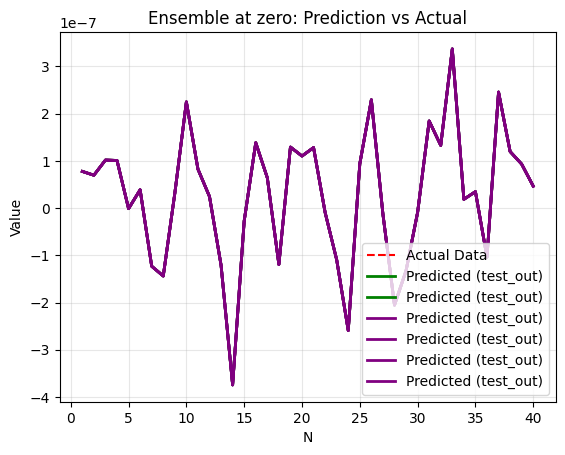

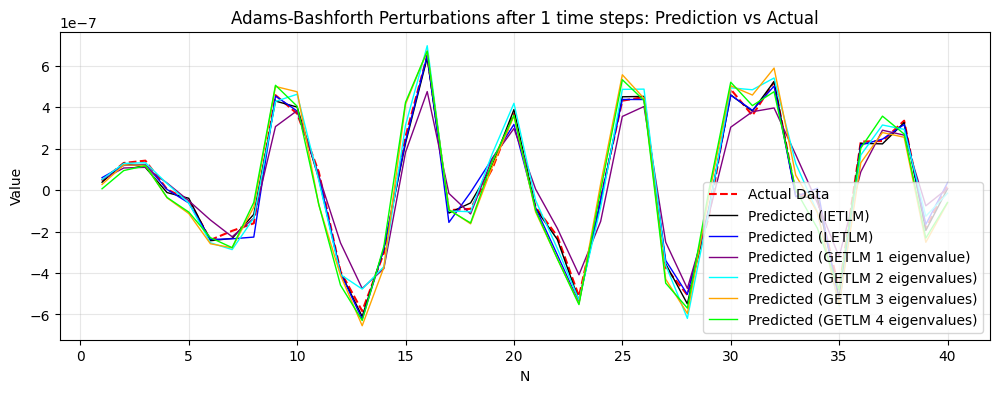

TLM Test GETLM (1): tensor(0.0826)
TLM Test GETLM (2): tensor(0.0350)
TLM Test GETLM (3): tensor(0.0541)
TLM Test GETLM (4): tensor(0.0503)
TLM Test IETLM: tensor(0.0050)


<Figure size 640x480 with 0 Axes>

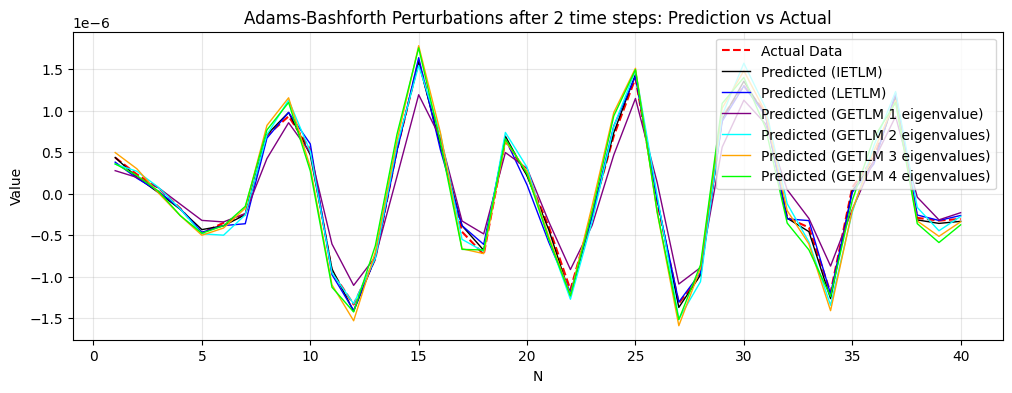

TLM Test GETLM (1): tensor(0.0669)
TLM Test GETLM (2): tensor(0.0225)
TLM Test GETLM (3): tensor(0.0332)
TLM Test GETLM (4): tensor(0.0331)
TLM Test IETLM: tensor(0.0030)


<Figure size 640x480 with 0 Axes>

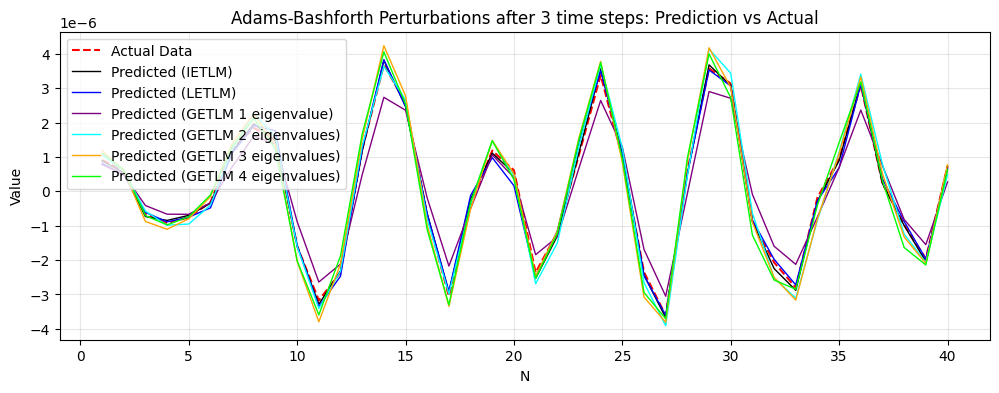

TLM Test GETLM (1): tensor(0.0634)
TLM Test GETLM (2): tensor(0.0189)
TLM Test GETLM (3): tensor(0.0278)
TLM Test GETLM (4): tensor(0.0263)
TLM Test IETLM: tensor(0.0022)


<Figure size 640x480 with 0 Axes>

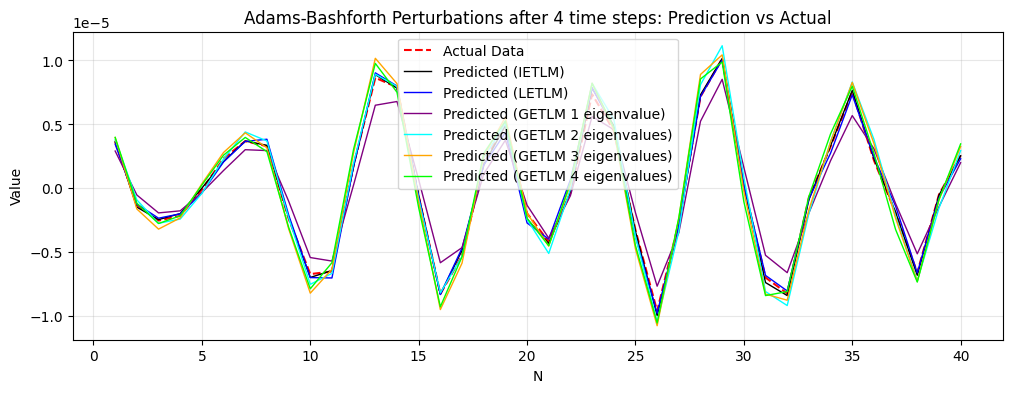

TLM Test GETLM (1): tensor(0.0597)
TLM Test GETLM (2): tensor(0.0171)
TLM Test GETLM (3): tensor(0.0246)
TLM Test GETLM (4): tensor(0.0224)
TLM Test IETLM: tensor(0.0016)


<Figure size 640x480 with 0 Axes>

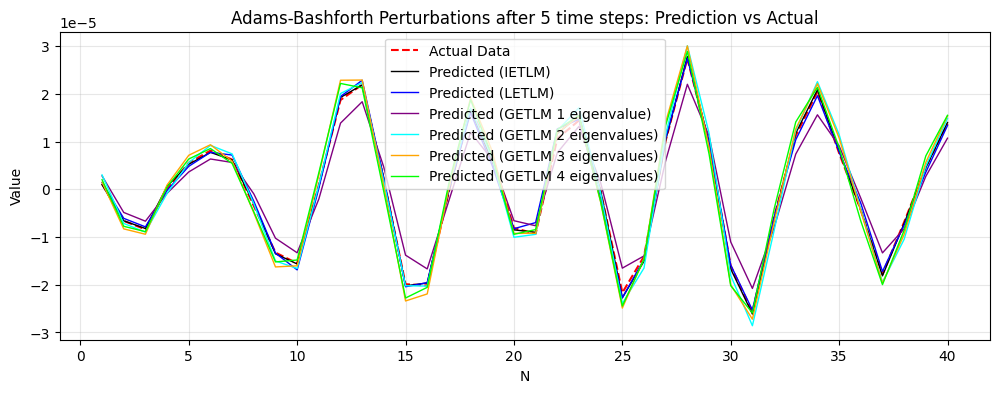

TLM Test GETLM (1): tensor(0.0578)
TLM Test GETLM (2): tensor(0.0163)
TLM Test GETLM (3): tensor(0.0227)
TLM Test GETLM (4): tensor(0.0202)
TLM Test IETLM: tensor(0.0014)


<Figure size 640x480 with 0 Axes>

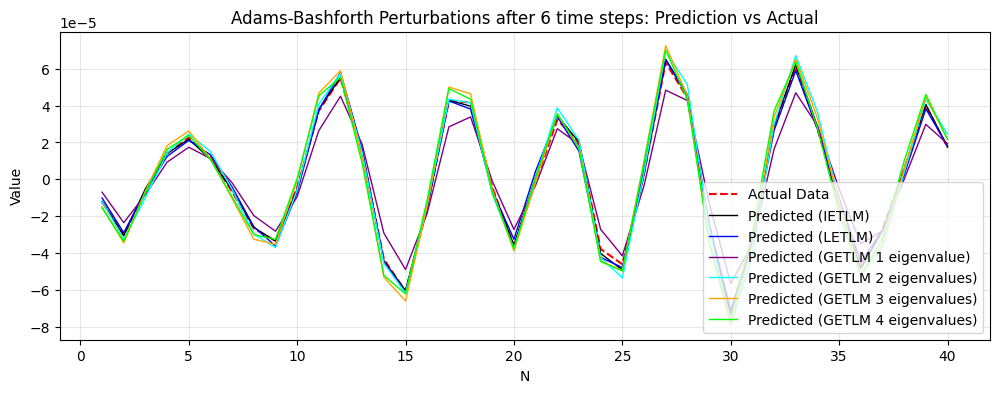

TLM Test GETLM (1): tensor(0.0566)
TLM Test GETLM (2): tensor(0.0160)
TLM Test GETLM (3): tensor(0.0215)
TLM Test GETLM (4): tensor(0.0188)
TLM Test IETLM: tensor(0.0012)


<Figure size 640x480 with 0 Axes>

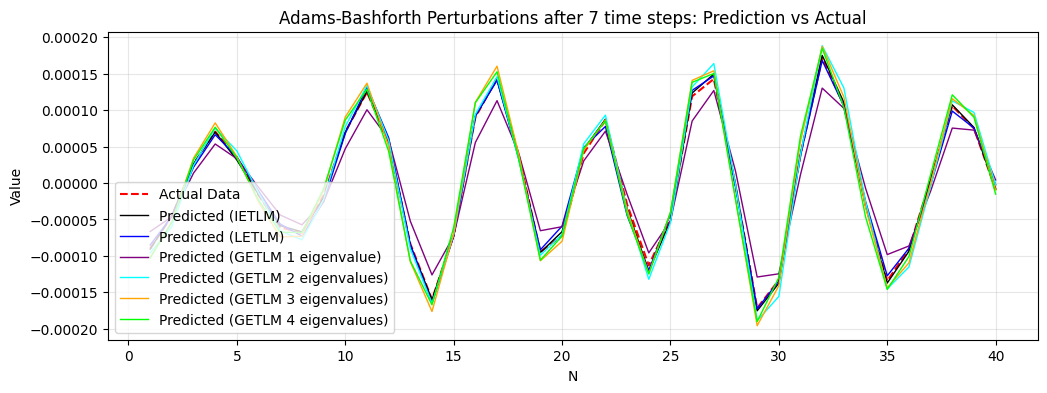

TLM Test GETLM (1): tensor(0.0560)
TLM Test GETLM (2): tensor(0.0158)
TLM Test GETLM (3): tensor(0.0205)
TLM Test GETLM (4): tensor(0.0179)
TLM Test IETLM: tensor(0.0012)


<Figure size 640x480 with 0 Axes>

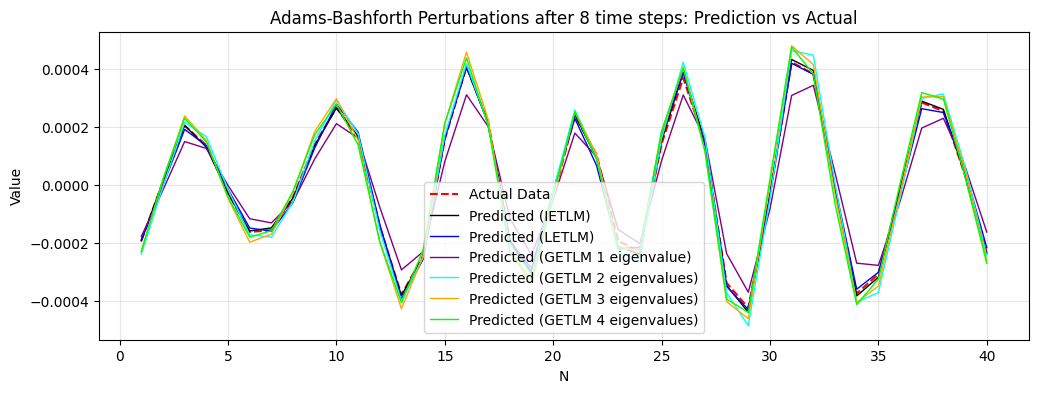

TLM Test GETLM (1): tensor(0.0555)
TLM Test GETLM (2): tensor(0.0159)
TLM Test GETLM (3): tensor(0.0197)
TLM Test GETLM (4): tensor(0.0172)
TLM Test IETLM: tensor(0.0011)


<Figure size 640x480 with 0 Axes>

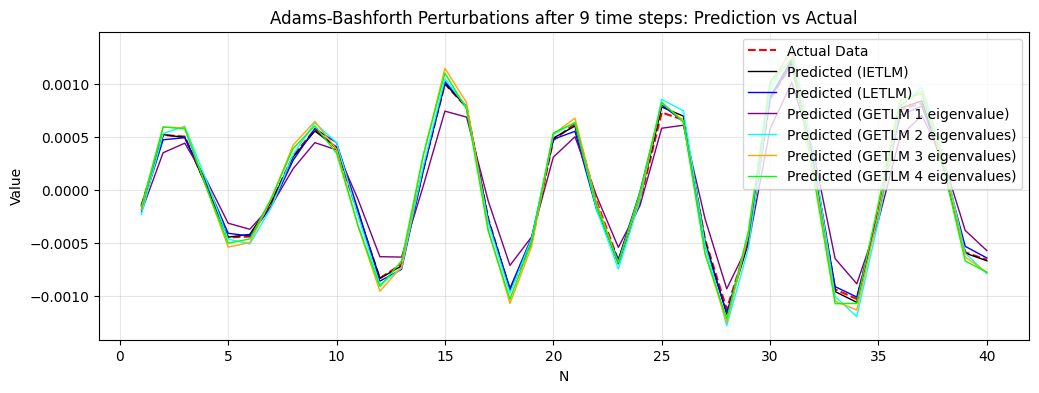

TLM Test GETLM (1): tensor(0.0552)
TLM Test GETLM (2): tensor(0.0160)
TLM Test GETLM (3): tensor(0.0190)
TLM Test GETLM (4): tensor(0.0168)
TLM Test IETLM: tensor(0.0011)


<Figure size 640x480 with 0 Axes>

In [20]:
# We will now compare the TLMS to the actual data to see 

# We first set a starting point for the TLMS
starting_time = 1

x_values = np.arange(1, N + 1)

IETLM_norm = []
GETLM_norm = []


IETLM_TT_result = []
LETLM_TT_result = []

GETLM_1_TT_result = []
GETLM_2_TT_result = []
GETLM_3_TT_result = []
GETLM_4_TT_result = []



# The first step is to get the test perturbation and then copy it for the IETLM, LETlM and GETLM 
test_0 = test_final_pert[1+starting_time]
IETLM_test = test_0
LETLM_test = test_0



GETLM_test_future_1 = test_0
GETLM_test_future_2 = test_0
GETLM_test_future_3 = test_0
GETLM_test_future_4 = test_0


GETLM_test_current_1 = test_final_pert[1+starting_time]
GETLM_test_current_2 = test_final_pert[1+starting_time]
GETLM_test_current_3 = test_final_pert[1+starting_time]
GETLM_test_current_4 = test_final_pert[1+starting_time]

# getlm_norm = L2_norm(GETLM_test_future, test_0)






index = 1+starting_time


IETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
LETLM_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )


GETLM_1_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_2_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_3_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )
GETLM_4_TT = TT.TLM_test(test_guess[index], unpert_run[index], test_0 )





IETLM_TT_result.append(IETLM_TT)
LETLM_TT_result.append(LETLM_TT)


GETLM_1_TT_result.append(GETLM_1_TT)
GETLM_2_TT_result.append(GETLM_2_TT)
GETLM_3_TT_result.append(GETLM_3_TT)
GETLM_4_TT_result.append(GETLM_4_TT)





plt.plot(x_values, test_0.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')

plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)
plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (test_out)', color='green', linewidth=2)



plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)
plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (test_out)', color='purple', linewidth=2)

plt.title(f"Ensemble at zero: Prediction vs Actual")
plt.xlabel("N")
plt.ylabel("Value")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop

# We will now go through the steps to see how each of the TLMS goes 
for i in range(len(test_final_pert)-3):
    index = i+2 + starting_time
    test = test_final_pert[i+2 + starting_time]


    # Ploting the IETLM
    ietlm = IETLMS[i+starting_time]
    IETLM_test = ietlm @ IETLM_test


    ietlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], IETLM_test)
    IETLM_TT_result.append(ietlm_tt)


    # Ploting the LETLM
    letlm = LETLMS[i+starting_time]
    LETLM_test = letlm @ LETLM_test


    letlm_tt = TT.TLM_test(test_guess[index], unpert_run[index], LETLM_test)
    LETLM_TT_result.append(letlm_tt)


    # IETLM_TT = torch.cat((IETLM_TT, ietlm_tt), dim = 0)



    GETLM_test_past_1 = GETLM_test_current_1
    GETLM_test_current_1 = GETLM_test_future_1

    GETLM_test_past_2 = GETLM_test_current_2
    GETLM_test_current_2 = GETLM_test_future_2

    GETLM_test_past_3 = GETLM_test_current_3
    GETLM_test_current_3 = GETLM_test_future_3

    GETLM_test_past_4 = GETLM_test_current_4
    GETLM_test_current_4 = GETLM_test_future_4

    NL = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][1]
    NK = torch.pinverse(GETLMS_1[i+starting_time][0]) @ GETLMS_1[i+starting_time][2]
    GETLM_test_future_1 = NL @ GETLM_test_current_1 + NK @ GETLM_test_past_1

    NL = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][1]
    NK = torch.pinverse(GETLMS_2[i+starting_time][0]) @ GETLMS_2[i+starting_time][2]
    GETLM_test_future_2 = NL @ GETLM_test_current_2 + NK @ GETLM_test_past_2
    
    NL = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][1]
    NK = torch.pinverse(GETLMS_3[i+starting_time][0]) @ GETLMS_3[i+starting_time][2]
    GETLM_test_future_3 = NL @ GETLM_test_current_3 + NK @ GETLM_test_past_3

    NL = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][1]
    NK = torch.pinverse(GETLMS_4[i+starting_time][0]) @ GETLMS_4[i+starting_time][2]
    GETLM_test_future_4 = NL @ GETLM_test_current_4 + NK @ GETLM_test_past_4

    getlm_tt_1 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_1)
    getlm_tt_2 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_2)
    getlm_tt_3 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_3)
    getlm_tt_4 = TT.TLM_test(test_guess[index], unpert_run[index], GETLM_test_future_4)


    # GETLM_TT = torch.cat((GETLM_TT, getlm_tt), dim = 0)
    GETLM_1_TT_result.append(getlm_tt_1)
    GETLM_2_TT_result.append(getlm_tt_2)
    GETLM_3_TT_result.append(getlm_tt_3)
    GETLM_4_TT_result.append(getlm_tt_4)




    

    # # We now need to calculate the L2 norm

    # letlm_norm = L2_norm(LETLM_test, test)
    # ietlm_norm = L2_norm(IETLM_test, test)
    # getlm_norm = L2_norm(GETLM_test_future, test)
    # print('IETLM norm:', ietlm_norm)
    # print('LETLM norm:', letlm_norm)
    # print('GETLM norm:', getlm_norm)
    # LETLM_norm.append(letlm_norm)
    # IETLM_norm.append(ietlm_norm)
    # GETLM_norm.append(getlm_norm)

    plt.figure(figsize=(12, 4))  # width=12 inches, height=4 inches
    # plt.ylim(-0.0015, 0.0015)


    plt.plot(x_values, test.detach().cpu().numpy(), label='Actual Data', color='red', linestyle='--')
    plt.plot(x_values, IETLM_test.detach().cpu().numpy(), label='Predicted (IETLM)', color='black', linewidth=1)
    plt.plot(x_values, LETLM_test.detach().cpu().numpy(), label='Predicted (LETLM)', color='blue', linewidth=1)

    plt.plot(x_values, GETLM_test_future_1.detach().cpu().numpy(), label='Predicted (GETLM 1 eigenvalue)', color='purple', linewidth=1)
    plt.plot(x_values, GETLM_test_future_2.detach().cpu().numpy(), label='Predicted (GETLM 2 eigenvalues)', color='aqua', linewidth=1)
    plt.plot(x_values, GETLM_test_future_3.detach().cpu().numpy(), label='Predicted (GETLM 3 eigenvalues)', color='orange', linewidth=1)
    plt.plot(x_values, GETLM_test_future_4.detach().cpu().numpy(), label='Predicted (GETLM 4 eigenvalues)', color='lime', linewidth=1)



    plt.title(f"Adams-Bashforth Perturbations after {i+1} time steps: Prediction vs Actual")

    plt.xlabel("N")
    plt.ylabel("Value")
    plt.legend()

    plt.grid(True, alpha=0.3)
    plt.show() # This creates a fresh window/plot for each step in the loop
    plt.clf()
    
    print('TLM Test GETLM (1):', getlm_tt_1)
    print('TLM Test GETLM (2):', getlm_tt_2)
    print('TLM Test GETLM (3):', getlm_tt_3)
    print('TLM Test GETLM (4):', getlm_tt_4)


    print('TLM Test IETLM:', ietlm_tt)

    
    # plt.plot(x_values, IETLM_test.detach().cpu().numpy() - test.detach().cpu().numpy(), label='Predicted (IETLM)', color='green', linewidth=1)
    # plt.show()
    # plt.clf()



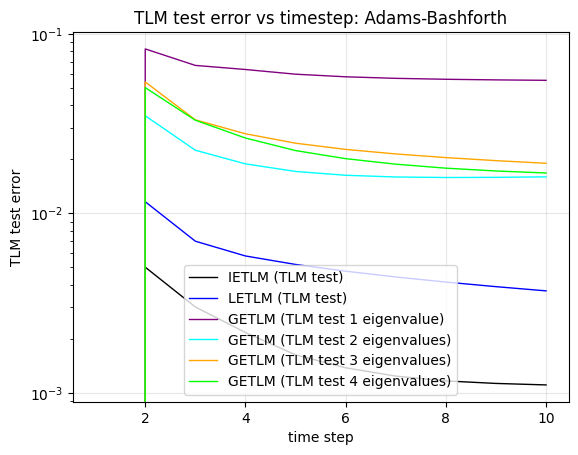

<Figure size 640x480 with 0 Axes>

In [21]:
x_values_norm = np.arange(1,len(IETLM_TT_result)+1)


plt.plot(x_values_norm, IETLM_TT_result, label='IETLM (TLM test)', color='black', linewidth=1)
plt.plot(x_values_norm, LETLM_TT_result, label='LETLM (TLM test)', color='blue', linewidth=1)

plt.plot(x_values_norm, GETLM_1_TT_result, label='GETLM (TLM test 1 eigenvalue)', color='purple', linewidth=1)
plt.plot(x_values_norm, GETLM_2_TT_result, label='GETLM (TLM test 2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values_norm, GETLM_3_TT_result, label='GETLM (TLM test 3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values_norm, GETLM_4_TT_result, label='GETLM (TLM test 4 eigenvalues)', color='lime', linewidth=1)

plt.title("TLM test error vs timestep: Adams-Bashforth")
plt.xlabel("time step")
plt.ylabel("TLM test error")
plt.legend()
plt.yscale('log')
plt.grid(True, alpha=0.3)
plt.show() # This creates a fresh window/plot for each step in the loop
plt.clf()


In [22]:
# import numpy as np
# import matplotlib.pyplot as plt

# # 1. Ensure your results are NumPy arrays
# ietlm = np.array(IETLM_TT_result)
# letlm = np.array(LETLM_TT_result)

# getlm1 = np.array(GETLM_1_TT_result)
# getlm2 = np.array(GETLM_2_TT_result)
# getlm3 = np.array(GETLM_3_TT_result)
# getlm4 = np.array(GETLM_4_TT_result)

# x_values_norm = np.arange(1, len(ietlm) + 1)

# # 2. Now you can perform element-wise division
# plt.plot(x_values_norm, letlm / ietlm, label='LETLM', color='blue', linewidth=1)
# plt.plot(x_values_norm, ietlm / ietlm, label='IETLM (Baseline = 1)', color='black', linewidth=1.5, linestyle='--')
# # plt.plot(x_values_norm, getlm1 / ietlm, label='GETLM (1 eigenvalue)', color='purple', linewidth=1)
# plt.plot(x_values_norm, getlm2 / ietlm, label='GETLM (2 eigenvalues)', color='aqua', linewidth=1)
# plt.plot(x_values_norm, getlm3 / ietlm, label='GETLM (3 eigenvalues)', color='orange', linewidth=1)
# plt.plot(x_values_norm, getlm4 / ietlm, label='GETLM (4 eigenvalues)', color='lime', linewidth=1)


# plt.axhline(y=1, color='black', linestyle=':', alpha=0.5)

# plt.title("Relative TLM Test Error vs Timestep (Normalized to IETLM)")
# plt.xlabel("Time Step")
# plt.ylabel("Relative Error (GETLM / IETLM)")
# plt.legend()
# plt.grid(True, alpha=0.3)
# plt.show()
# plt.clf()

# # ... rest of your plot code

/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_48351/1206223297.py:16: RuntimeWarning: invalid value encountered in divide
  plt.plot(x_values_norm, letlm / letlm, label='LETLM (Baseline = 1)', color='blue', linewidth=1.5, linestyle='--')
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_48351/1206223297.py:20: RuntimeWarning: invalid value encountered in divide
  plt.plot(x_values_norm, getlm2 / letlm, label='GETLM (2 eigenvalues)', color='aqua', linewidth=1)
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_48351/1206223297.py:21: RuntimeWarning: invalid value encountered in divide
  plt.plot(x_values_norm, getlm3 / letlm, label='GETLM (3 eigenvalues)', color='orange', linewidth=1)
/var/folders/n6/ghh1_ly93_54z8g_dcc6wj7c0000gp/T/ipykernel_48351/1206223297.py:22: RuntimeWarning: invalid value encountered in divide
  plt.plot(x_values_norm, getlm4 / letlm, label='GETLM (4 eigenvalues)', color='lime', linewidth=1)


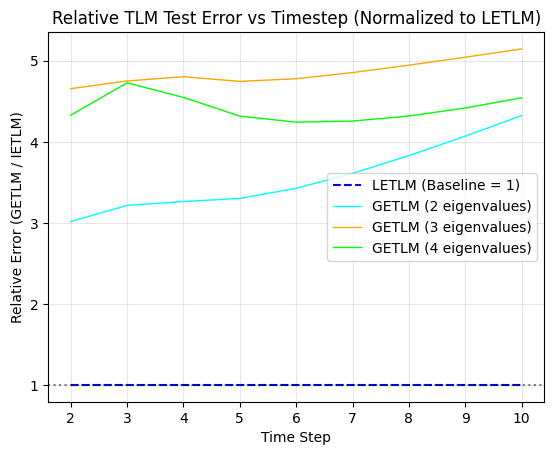

<Figure size 640x480 with 0 Axes>

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Ensure your results are NumPy arrays
ietlm = np.array(IETLM_TT_result)
letlm = np.array(LETLM_TT_result)

getlm1 = np.array(GETLM_1_TT_result)
getlm2 = np.array(GETLM_2_TT_result)
getlm3 = np.array(GETLM_3_TT_result)
getlm4 = np.array(GETLM_4_TT_result)

x_values_norm = np.arange(1, len(ietlm) + 1)

# 2. Now you can perform element-wise division
plt.plot(x_values_norm, letlm / letlm, label='LETLM (Baseline = 1)', color='blue', linewidth=1.5, linestyle='--')
# plt.plot(x_values_norm, ietlm / letlm, label='IETLM ', color='black', linewidth=1)
# plt.plot(x_values_norm, getlm1 / letlm, label='GETLM (1 eigenvalue)', color='purple', linewidth=1)

plt.plot(x_values_norm, getlm2 / letlm, label='GETLM (2 eigenvalues)', color='aqua', linewidth=1)
plt.plot(x_values_norm, getlm3 / letlm, label='GETLM (3 eigenvalues)', color='orange', linewidth=1)
plt.plot(x_values_norm, getlm4 / letlm, label='GETLM (4 eigenvalues)', color='lime', linewidth=1)


plt.axhline(y=1, color='black', linestyle=':', alpha=0.5)

plt.title("Relative TLM Test Error vs Timestep (Normalized to LETLM)")
plt.xlabel("Time Step")
plt.ylabel("Relative Error (GETLM / IETLM)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
plt.clf()

# ... rest of your plot code